In [1]:
import numpy as np
import torch
from matrixgame import MatrixGame, SequentialVAE, SequentialVQVAE, EMGFlowNet
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [9]:
game = MatrixGame()
# net = SequentialVAE(latent_dim=2)
# net = SequentialVQVAE(2, 4, 1)
net = EMGFlowNet(state_size=2, dict_size=8)
if net._get_name() != "EMGFlowNet":
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
batch = 32
repetitions = 20
dec_losses, kl_losses = [], []

for epoch in (pbar := tqdm(range(2000))):
    # own_actions = np.random.randint(0, 2, (batch, repetitions))
    own_actions = np.zeros((batch, repetitions))
    other_actions = np.zeros_like(own_actions)
    rewards = np.zeros((batch, repetitions))
    for gg in range(batch):
        game.reset()
        sw = False
        for t in range(repetitions):
            other_action, reward = game.step(own_actions[gg, t])
            if other_action == 0 and sw == False:
                sw = True
                own_actions[gg, t+1:] = np.tile(np.concatenate([np.zeros(t), [1]]), 30)[:repetitions-t-1]
            other_actions[gg, t], rewards[gg, t] = other_action, reward
    actions = torch.from_numpy(np.stack([own_actions, other_actions], axis=-1)).float()
    rewards = torch.from_numpy(rewards).unsqueeze(-1).float()

    if net._get_name() == "SequentialVAE":
        dec_loss, kl_loss, _, _ = net(actions, rewards)
        loss = dec_loss + 0.05 * kl_loss
        dec_losses.append(dec_loss.item())
        kl_losses.append(kl_loss.item())
    if net._get_name() == "SequentialVQVAE":
        dec_loss, q_loss, _, _, _, _ = net(actions, rewards)
        loss = dec_loss + q_loss
        dec_losses.append(dec_loss.item())
        kl_losses.append(q_loss.item())
    if net._get_name() == "EMGFlowNet":
        if (epoch % 200) < 100:
            gfn_loss = net.train_gfn(actions, rewards, rand_prob=0.3)
            kl_losses.append(gfn_loss)
            pbar.set_description(f"GFN Loss: {kl_losses[-1]:.4f}")
        else:
            dec_loss = net.train_decoder(actions, rewards, prob_exponent=-1)
            dec_losses.append(dec_loss)
            pbar.set_description(f"Dec Loss: {dec_losses[-1]:.4f}")
    if net._get_name() != "EMGFlowNet":
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pbar.set_description(f"Dec Loss: {dec_losses[-1]:.4f}, KL Loss: {kl_losses[-1]:.4f}")

  0%|          | 0/2000 [00:00<?, ?it/s]

In [10]:
# plt.plot(dec_losses)
# plt.plot(kl_losses)
game = MatrixGame()
ms, mts = [], []
for ag in [1, 2, 3]:
    game.reset(agent_type=ag)
    test_other_actions, test_rewards = torch.zeros(repetitions), torch.zeros(repetitions)
    test_own_actions = torch.zeros(repetitions)
    sw = False
    for t in range(repetitions):
        other_action, reward = game.step(test_own_actions[t].item())
        if other_action == 0 and sw == False:
            sw = True
            test_own_actions[t+1:] = torch.cat([torch.zeros(t), torch.tensor([1])]).tile(30)[:repetitions-t-1]
        test_other_actions[t], test_rewards[t] = other_action, reward
    test_actions = torch.cat([test_own_actions.unsqueeze(1), test_other_actions.unsqueeze(1)], dim=-1).unsqueeze(0)
    test_rewards = test_rewards.unsqueeze(0).unsqueeze(-1)
    if net._get_name() == "SequentialVAE":
        _, _, m, m_t = net(test_actions, test_rewards)
    if net._get_name() == "SequentialVQVAE":
        _, _, _, _, m, m_t = net(test_actions, test_rewards)
    if net._get_name() == "EMGFlowNet":
        _, _, m, m_t = net.sample_latents(test_actions, test_rewards, rand_prob=0, prob_exponent=-1)
    m, m_t = m.squeeze().detach().numpy(), m_t.squeeze().detach().numpy()
    ms.append(m)
    mts.append(m_t)
ms, mts = np.stack(ms), np.stack(mts)

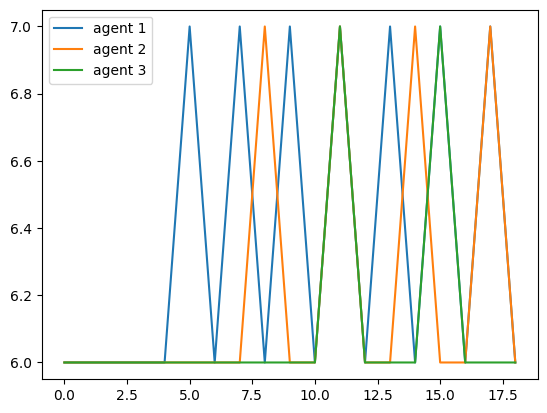

In [17]:
plt.plot(ms[..., 0].transpose())
plt.legend(["agent 1", "agent 2", "agent 3"])